In [1]:
import os
base = '/kaggle/input/datasets/irfan020/race-preprocessed/processed'
print(os.listdir(base))

['train_options.csv', 'test_options.csv', 'train_clean.csv', 'dev_clean.csv', 'dev_options.csv', 'test_clean.csv']


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

BASE       = '/kaggle/input/datasets/irfan020/race-preprocessed/processed'
IMAGES     = '/kaggle/working/eda_images'
os.makedirs(IMAGES, exist_ok=True)


In [3]:
train_df      = pd.read_csv(f'{BASE}/train_clean.csv')
dev_df        = pd.read_csv(f'{BASE}/dev_clean.csv')
test_df       = pd.read_csv(f'{BASE}/test_clean.csv')
train_options = pd.read_csv(f'{BASE}/train_options.csv')

print(f'Train: {train_df.shape}')
print(f'Dev:   {dev_df.shape}')
print(f'Test:  {test_df.shape}')
print(f'\nColumns: {train_df.columns.tolist()}')
print(f'\nSample row:')
print(train_df.iloc[0])

Train: (70292, 9)
Dev:   (8787, 9)
Test:  (8787, 9)

Columns: ['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

Sample row:
Unnamed: 0                                                20564
id                                               middle1585.txt
article       walt disney began to make cartoon movies when ...
question                when disney began making cartoon movies
A                                              he was very poor
B                                          the mouse helped him
C                                his wife knew nothing about it
D                            people didn t like cartoons at all
answer                                                        A
Name: 0, dtype: object


In [4]:
print('BASIC STATISTICS')
print(f'Total samples:      {len(train_df) + len(dev_df) + len(test_df)}')
print(f'Train samples:      {len(train_df)}')
print(f'Dev samples:        {len(dev_df)}')
print(f'Test samples:       {len(test_df)}')
print(f'\nMissing values (train):')
print(train_df.isnull().sum())
print(f'\nAnswer Distribution:')
print(train_df['answer'].value_counts().sort_index())

BASIC STATISTICS
Total samples:      87866
Train samples:      70292
Dev samples:        8787
Test samples:       8787

Missing values (train):
Unnamed: 0     0
id             0
article        0
question      19
A             39
B             39
C             45
D             46
answer         0
dtype: int64

Answer Distribution:
answer
A    15257
B    18141
C    19091
D    17803
Name: count, dtype: int64


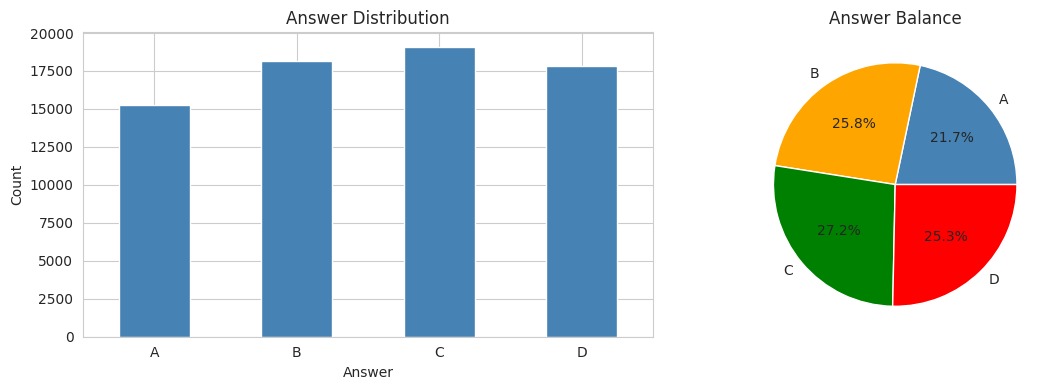

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['answer'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('Answer Distribution')
axes[0].set_xlabel('Answer')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

train_df['answer'].value_counts().sort_index().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['steelblue', 'orange', 'green', 'red'],
    ax=axes[1])
axes[1].set_title('Answer Balance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{IMAGES}/01_answer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
train_df['article_len']  = train_df['article'].apply(lambda x: len(str(x).split()))
train_df['question_len'] = train_df['question'].apply(lambda x: len(str(x).split()))
train_df['option_len']   = train_df['A'].apply(lambda x: len(str(x).split()))

print('Article Length Stats:')
print(train_df['article_len'].describe())
print('\nQuestion Length Stats:')
print(train_df['question_len'].describe())

Article Length Stats:
count    70292.000000
mean       282.044600
std        100.340455
min          2.000000
25%        222.000000
50%        287.000000
75%        334.000000
max       1188.000000
Name: article_len, dtype: float64

Question Length Stats:
count    70292.000000
mean         9.246586
std          3.436891
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         64.000000
Name: question_len, dtype: float64


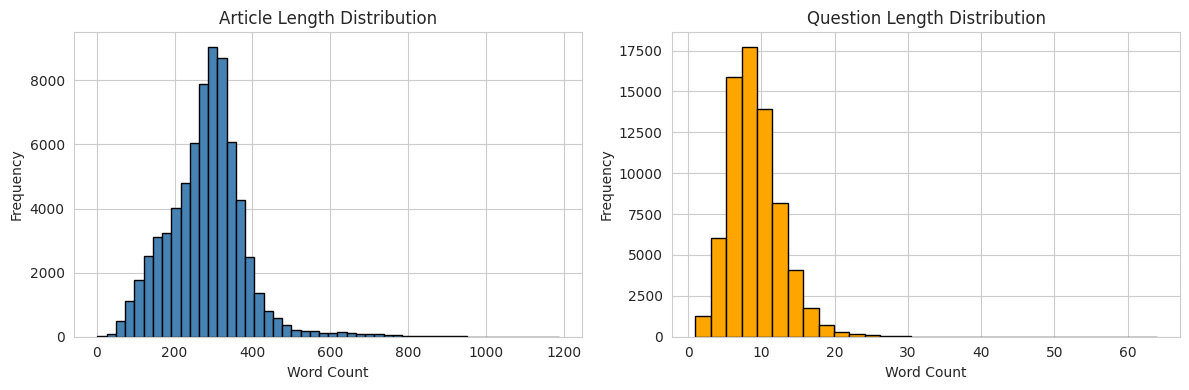

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['article_len'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Article Length Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(train_df['question_len'], bins=30, color='orange', edgecolor='black')
axes[1].set_title('Question Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f'{IMAGES}/02_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

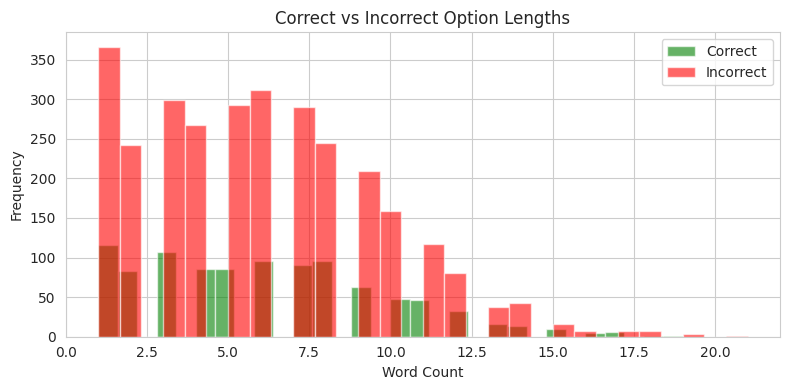

Avg correct length:   6.04 words
Avg incorrect length: 5.87 words


In [8]:
lengths = {'correct': [], 'incorrect': []}
for _, row in train_df.head(1000).iterrows():
    for opt in ['A', 'B', 'C', 'D']:
        length = len(str(row[opt]).split())
        if row['answer'] == opt:
            lengths['correct'].append(length)
        else:
            lengths['incorrect'].append(length)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths['correct'],   bins=30, alpha=0.6, label='Correct',   color='green')
ax.hist(lengths['incorrect'], bins=30, alpha=0.6, label='Incorrect', color='red')
ax.set_title('Correct vs Incorrect Option Lengths')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMAGES}/03_option_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg correct length:   {np.mean(lengths["correct"]):.2f} words')
print(f'Avg incorrect length: {np.mean(lengths["incorrect"]):.2f} words')

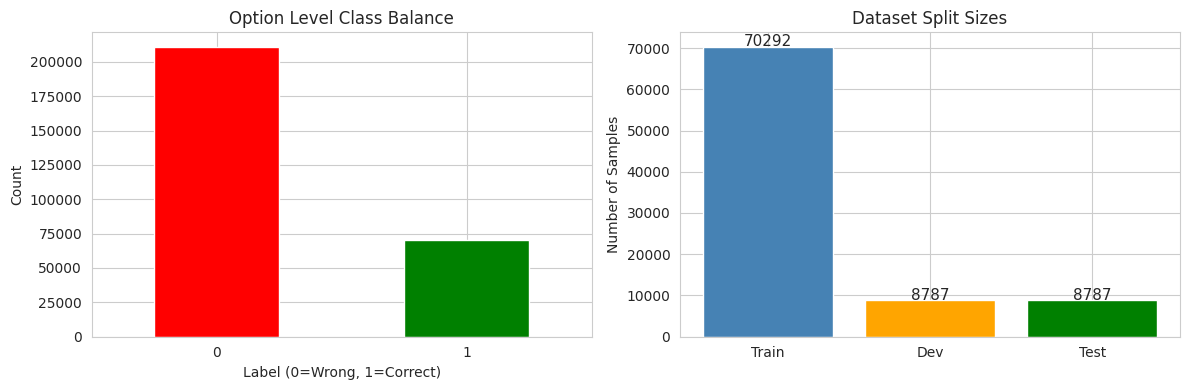

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Option level balance
train_options['label'].value_counts().plot(
    kind='bar', color=['red', 'green'], ax=axes[0])
axes[0].set_title('Option Level Class Balance')
axes[0].set_xlabel('Label (0=Wrong, 1=Correct)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Dataset split sizes
splits = ['Train', 'Dev', 'Test']
sizes  = [len(train_df), len(dev_df), len(test_df)]
bars   = axes[1].bar(splits, sizes, color=['steelblue', 'orange', 'green'])
axes[1].set_title('Dataset Split Sizes')
axes[1].set_ylabel('Number of Samples')
for bar, size in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 str(size), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{IMAGES}/04_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
summary = pd.DataFrame({
    'Metric': [
        'Total Samples', 'Train Samples', 'Dev Samples', 'Test Samples',
        'Avg Article Length', 'Avg Question Length',
        'Class Balance (Correct)', 'Unique Answers'
    ],
    'Value': [
        len(train_df) + len(dev_df) + len(test_df),
        len(train_df), len(dev_df), len(test_df),
        f"{train_df['article_len'].mean():.1f} words",
        f"{train_df['question_len'].mean():.1f} words",
        f"{train_options['label'].mean():.2f} (25% expected)",
        train_df['answer'].nunique()
    ]
})

print('DATASET SUMMARY')
print(summary.to_string(index=False))

# Save summary
summary.to_csv(f'{IMAGES}/eda_summary.csv', index=False)
print('Images saved:', os.listdir(IMAGES))

DATASET SUMMARY
                 Metric               Value
          Total Samples               87866
          Train Samples               70292
            Dev Samples                8787
           Test Samples                8787
     Avg Article Length         282.0 words
    Avg Question Length           9.2 words
Class Balance (Correct) 0.25 (25% expected)
         Unique Answers                   4
Images saved: ['eda_summary.csv', '03_option_lengths.png', '02_length_distribution.png', '01_answer_distribution.png', '04_class_balance.png']
